In [11]:
import pandas as pd
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(n_samples=750, centers=centers, cluster_std=0.5, random_state=42)

X = StandardScaler().fit_transform(X)
df = pd.DataFrame({"f1": X[:, 0], "f2": X[:, 1]})
df.head()

,f1,f2
0,0.263253,-0.229350
1,0.438413,0.856881
2,-0.536834,-0.682501
3,-2.138955,-0.817296
4,0.749334,1.173927


C:\Users\hapatil\AppData\Local\Temp\ipykernel_18728\414509860.py:1: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(data=df, x="f1", y="f2",  palette="Set1")


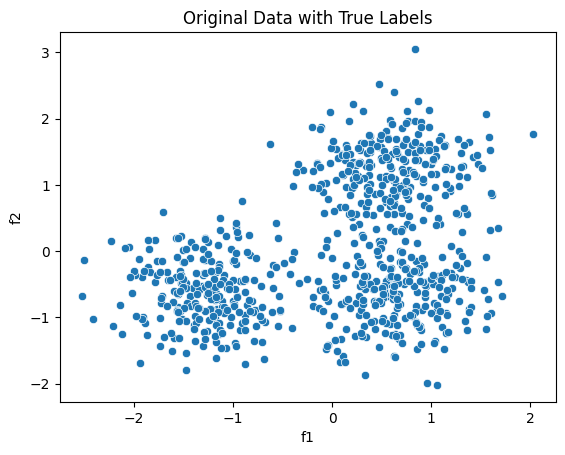

In [13]:
sns.scatterplot(data=df, x="f1", y="f2",  palette="Set1")
plt.title("Original Data with True Labels")
plt.show()

In [25]:
from sklearn.cluster import DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=10)
dbscan.fit(df[["f1", "f2"]])
df["dbscan_label"] = dbscan.labels_
df.head()

,f1,f2,dbscan_label
0,0.263253,-0.229350,2
1,0.438413,0.856881,0
2,-0.536834,-0.682501,-1
3,-2.138955,-0.817296,-1
4,0.749334,1.173927,0


In [26]:
list(dbscan.labels_).count(-1)

164

In [27]:
df.head()

,f1,f2,dbscan_label
0,0.263253,-0.229350,2
1,0.438413,0.856881,0
2,-0.536834,-0.682501,-1
3,-2.138955,-0.817296,-1
4,0.749334,1.173927,0


In [28]:
df.groupby("dbscan_label").size()

dbscan_label
-1    164
 0    205
 1    189
 2    186
 3      6
dtype: int64

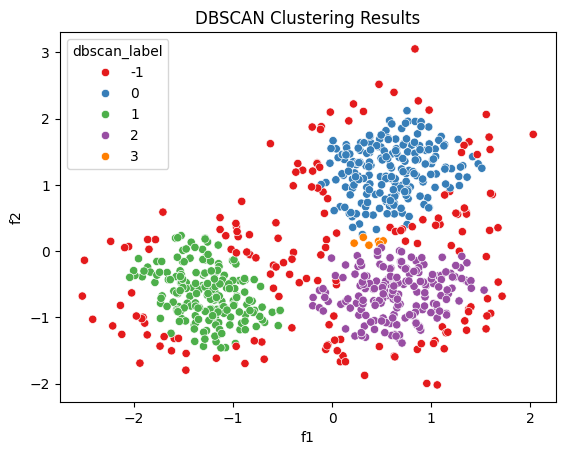

In [29]:
sns.scatterplot(data=df, x="f1", y="f2", hue="dbscan_label", palette="Set1")
plt.title("DBSCAN Clustering Results")
plt.show()